# PoC v4 — MatryoshkaBatchTopK SAE: Frozen Core + FR Domain Adaptation

**Status:** Work In Progress.

**Architecture.** A pre-trained BatchTopK SAE (GPT-2-small, `gpt2-small-res-jb`, layer 6
`hook_resid_pre`) is *frozen* via gradient hooks and wrapped inside a Matryoshka SAE whose
**extra** features are the only trainable parameters. Training data: French technical
Wikipedia (energy, electrical engineering, industrial automation).

**Hypotheses.**
1. The Matryoshka (frozen core) improves FVE on French *without* degrading English (no catastrophic forgetting).
2. Direct fine-tuning (unfrozen core) improves French but induces measurable forgetting on English.
3. The extra features learn concepts distinct from the core, observable through max-activating tokens.

**Runtime.** Designed for Google Colab **T4 (12 GB VRAM)**. Models are trained and evaluated
sequentially with explicit memory release between runs. The Matryoshka `state_dict` is moved to
CPU before deletion so the interpretability cell can reload it.


In [1]:
!pip install -q sae_lens transformers datasets torch transformer_lens matplotlib

import gc
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from sae_lens import SAE
from sae_lens.saes.batchtopk_sae import BatchTopKTrainingSAE, BatchTopKTrainingSAEConfig
from sae_lens.saes.matryoshka_batchtopk_sae import (
    MatryoshkaBatchTopKTrainingSAE,
    MatryoshkaBatchTopKTrainingSAEConfig,
)
from sae_lens.saes.sae import TrainStepInput
from transformer_lens import HookedTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.9/290.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 945.3/945.3 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.6/236.6 kB 25.8 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4
Total VRAM: 15.6 GB


## 1. Pre-trained SAE and hyperparameters


In [2]:
# ---- Model / SAE identifiers ------------------------------------------------
LAYER   = 6
RELEASE = "gpt2-small-res-jb"
SAE_ID  = f"blocks.{LAYER}.hook_resid_pre"
HOOK_NAME = SAE_ID  # single source of truth, reused everywhere below

# ---- Training hyperparameters (tuned for Colab T4) --------------
# Data volume
N_PAGES      = 3000   # French Wikipedia pages kept after keyword filtering
MAX_CHUNKS   = 6      # chunks of CHUNK_LENGTH chars per page
CHUNK_LENGTH = 1024
N_TOTAL      = 3000   # pages actually encoded to activations
N_EN_TEXTS   = 500    # TinyStories samples for the EN evaluation set
MAX_LENGTH   = 128    # tokens per chunk
BATCH_ENC    = 16     # texts per LLM forward pass (activation extraction)

# SAE sizes
K_CORE   = 50
D_EXTRA  = 1024
K_EXTRA  = 16

# Training loop
EPOCHS_MAT   = 50     # matryoshka (only extra weights trainable)
EPOCHS_FT    = 20     # full fine-tuning
LR_MAT       = 3e-4   # higher LR: only a small slice of weights receives gradients
LR_FT        = 1e-5   # conservative LR to limit forgetting on EN
BATCH_TRAIN  = 512    # >= 512 required by BatchTopK threshold estimator

pretrained_sae = SAE.from_pretrained(release=RELEASE, sae_id=SAE_ID, device=DEVICE)
pretrained_sae.eval()

D_IN       = pretrained_sae.cfg.d_in
D_SAE_CORE = pretrained_sae.cfg.d_sae
D_TOTAL    = D_SAE_CORE + D_EXTRA
model_kwargs = getattr(pretrained_sae.cfg, "model_from_pretrained_kwargs", {}) or {}

print(f"d_in={D_IN}, d_core={D_SAE_CORE}, d_extra={D_EXTRA}, d_total={D_TOTAL}")
print(f"k_core={K_CORE}, k_extra={K_EXTRA}, k_total={K_CORE + K_EXTRA}")


cfg.json: 0.00B [00:00, ?B/s]

blocks.6.hook_resid_pre/sae_weights.safe(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

blocks.6.hook_resid_pre/sparsity.safeten(…):   0%|          | 0.00/98.4k [00:00<?, ?B/s]

d_in=768, d_core=24576, d_extra=1024, d_total=25600
k_core=50, k_extra=16, k_total=66


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


## 2. Dataset — French technical Wikipedia


In [3]:
TECH_KEYWORDS = [
    "énergie", "électrique", "thermique", "nucléaire", "hydraulique",
    "réseau électrique", "turbine", "réacteur", "transformateur",
    "puissance", "tension électrique", "courant électrique",
    "centrale électrique", "ligne haute tension", "barrage",
    "photovoltaïque", "éolien", "cogénération", "sous-station",
    "ingénierie", "système de contrôle",
    "maintenance industrielle", "capteur",
    "asservissement", "automate programmable", "SCADA",
    "instrumentation", "mécanique des fluides", "thermodynamique",
    "génie civil", "béton armé", "soudure", "corrosion",
    "sécurité industrielle",
    "habilitation électrique", "risque électrique",
]

dataset = load_dataset("wikimedia/wikipedia", "20231101.fr", split="train", streaming=True)
dataset_filtered = (
    dataset
    .filter(lambda ex: any(kw in ex["text"].lower() for kw in TECH_KEYWORDS))
    .shuffle(buffer_size=1000, seed=42)
)

texts = []
for d in dataset_filtered.take(N_PAGES):
    txt = d["text"].replace("\n", " ").strip()
    texts.extend(
        [txt[i:i + CHUNK_LENGTH] for i in range(0, len(txt), CHUNK_LENGTH)][:MAX_CHUNKS]
    )
print(f"FR segments collected: {len(texts)}")


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

FR segments collected: 12454


## 3. Source model (TransformerLens)

The `jb` SAEs were trained with `center_writing_weights=True` and `fold_ln=True`. Passing
`model_kwargs` to `HookedTransformer.from_pretrained` guarantees the GPT-2 activations live in
the exact distribution seen by the pre-trained SAE, so no extra scaling is required.


In [4]:
tl_model = HookedTransformer.from_pretrained("gpt2", **model_kwargs).to(DEVICE)
tl_model.eval()


def get_activations_batch(texts, batch_size=BATCH_ENC, max_length=MAX_LENGTH):
    """Return layer-LAYER residual stream activations [N_tokens, D_IN] on CPU."""
    all_acts = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            tokens = tl_model.to_tokens(batch_texts, prepend_bos=True).to(DEVICE)
            tokens = tokens[:, :max_length]
            _, cache = tl_model.run_with_cache(tokens, names_filter=HOOK_NAME)
            acts = cache[HOOK_NAME]  # already in the SAE's input distribution
            all_acts.append(acts.reshape(-1, D_IN).cpu())
            del cache
    return torch.cat(all_acts, dim=0)


print(f"HookedTransformer ready on {next(tl_model.parameters()).device}")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
HookedTransformer ready on cuda:0


## 4. Architecture — `EncapsulatedMatryoshkaBatchTopK`

**Invariant.** For every training step $t > 0$, $\nabla_{\theta_{\text{core}}}\mathcal{L} = 0$
thanks to per-tensor gradient hooks. Only $W_{\text{enc}}[:, d_{\text{core}}:]$,
$W_{\text{dec}}[d_{\text{core}}:, :]$ and $b_{\text{enc}}[d_{\text{core}}:]$ receive gradients.


In [5]:
class EncapsulatedMatryoshkaBatchTopK(nn.Module):
    """SAELens layout: W_enc [d_in, d_sae], W_dec [d_sae, d_in], b_enc [d_sae].

    Core subspace  = columns/rows [:d_core] -> frozen via gradient hooks.
    Extra subspace = columns/rows [d_core:] -> trainable.
    """

    def __init__(self, pretrained: SAE, d_extra: int, k_extra: int):
        super().__init__()
        d_core  = pretrained.cfg.d_sae
        d_total = d_core + d_extra
        self.d_core = d_core

        mat_cfg = MatryoshkaBatchTopKTrainingSAEConfig(
            d_in=pretrained.cfg.d_in,
            d_sae=d_total,
            k=K_CORE + k_extra,
            matryoshka_widths=[d_core, d_total],
            device=DEVICE,
        )
        self.mat_sae = MatryoshkaBatchTopKTrainingSAE(mat_cfg)

        # Copy pre-trained weights into the core subspace.
        with torch.no_grad():
            self.mat_sae.W_enc.data[:, :d_core] = pretrained.W_enc.data
            self.mat_sae.W_dec.data[:d_core, :] = pretrained.W_dec.data
            self.mat_sae.b_enc.data[:d_core]    = pretrained.b_enc.data
            if hasattr(pretrained, "b_dec"):
                self.mat_sae.b_dec.data.copy_(pretrained.b_dec.data)

        # Zero-out gradients on the core subspace at every backward pass.
        self.mat_sae.W_enc.register_hook(self._freeze_enc)
        self.mat_sae.W_dec.register_hook(self._freeze_dec)
        self.mat_sae.b_enc.register_hook(self._freeze_b_enc)

    def _freeze_enc(self, g):
        g = g.clone(); g[:, :self.d_core] = 0.0; return g

    def _freeze_dec(self, g):
        g = g.clone(); g[:self.d_core, :] = 0.0; return g

    def _freeze_b_enc(self, g):
        g = g.clone(); g[:self.d_core] = 0.0; return g

    def forward(self, x: torch.Tensor):
        step_input = TrainStepInput(
            sae_in=x, coefficients={},
            dead_neuron_mask=None, n_training_steps=0, is_logging_step=False,
        )
        return self.mat_sae.training_forward_pass(step_input)


print("Architecture defined.")


Architecture defined.


## 5. Training and metrics utilities

- BatchTopK estimates its sparsity threshold at the batch level, so `batch_size >= 512` is required.
- $\text{FVE} = 1 - \text{MSE} / \text{Var}(x)$ with $\text{Var}(x) = \sum_j \sigma^2_j$
  (sum of per-feature variances).


In [6]:
def _make_step_input(acts):
    return TrainStepInput(
        sae_in=acts, coefficients={},
        dead_neuron_mask=None, n_training_steps=0, is_logging_step=False,
    )


def _forward(model, acts):
    # EncapsulatedMatryoshkaBatchTopK exposes its own forward; raw training SAEs don't.
    if hasattr(model, "mat_sae"):
        return model(acts)
    return model.training_forward_pass(_make_step_input(acts))


def compute_metrics(model, acts: torch.Tensor, batch_size: int = 4096):
    """MSE / FVE / L0 over the whole `acts` tensor, computed in mini-batches on GPU."""
    model.eval()
    mse_acc, l0_acc, n_tok = 0.0, 0.0, 0
    with torch.no_grad():
        for i in range(0, acts.shape[0], batch_size):
            b = acts[i:i + batch_size].to(DEVICE)
            out = _forward(model, b)
            recon = out.sae_out      if hasattr(out, "sae_out")      else out["sae_out"]
            feat  = out.feature_acts if hasattr(out, "feature_acts") else out["feature_acts"]
            mse_acc += (b - recon).pow(2).sum(dim=-1).sum().item()
            l0_acc  += (feat.abs() > 1e-6).float().sum(dim=-1).sum().item()
            n_tok   += b.shape[0]
    mse = mse_acc / n_tok
    l0  = l0_acc / n_tok
    var_total = acts.float().var(dim=0).sum().item()
    fve = 1.0 - (mse / (var_total + 1e-8))
    model.train()
    return {"MSE": mse, "FVE": fve, "L0": l0}


def train_sae_on_activations(
    model, acts_all: torch.Tensor,
    epochs: int, lr: float,
    batch_size: int = BATCH_TRAIN, log_every: int = 50,
):
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad], lr=lr,
    )
    model.train()
    N = acts_all.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(N)
        acts_s = acts_all[perm]
        for step, start in enumerate(range(0, N - batch_size, batch_size)):
            b = acts_s[start:start + batch_size].to(DEVICE)
            out = _forward(model, b)
            loss = out.loss if hasattr(out, "loss") else out["loss"]
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            if step % log_every == 0 and epoch % 5 == 0:
                print(f"  ep={epoch} step={step:4d} | loss={loss.item():.4f}")
    return model


def _copy_core_weights(dst, src):
    """Copy pre-trained core weights into a freshly constructed BatchTopK SAE."""
    with torch.no_grad():
        dst.W_enc.data.copy_(src.W_enc.data)
        dst.W_dec.data.copy_(src.W_dec.data)
        dst.b_enc.data.copy_(src.b_enc.data)
        if hasattr(src, "b_dec"):
            dst.b_dec.data.copy_(src.b_dec.data)


## 6. Activation pre-computation (single LLM pass)


In [7]:
gc.collect(); torch.cuda.empty_cache()

print(f"Computing FR activations on {N_TOTAL} segments...")
acts_raw = get_activations_batch(texts[:N_TOTAL])

idx   = torch.randperm(acts_raw.shape[0])
split = int(len(idx) * 0.85)
acts_train = acts_raw[idx[:split]].cpu()
acts_test  = acts_raw[idx[split:]].cpu()
del acts_raw
gc.collect(); torch.cuda.empty_cache()

print("Computing EN activations (TinyStories)...")
ds_en = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
en_texts = [d["text"][:1000] for d in ds_en.take(N_EN_TEXTS)]
acts_en = get_activations_batch(en_texts).cpu()

print("\nActivations ready:")
print(f"  FR Train : {acts_train.shape}")
print(f"  FR Test  : {acts_test.shape}")
print(f"  EN Test  : {acts_en.shape}")
print(f"VRAM allocated: {torch.cuda.memory_allocated(DEVICE) / 1e6:.0f} MB")


Computing FR activations on 3000 segments...
Computing EN activations (TinyStories)...


README.md: 0.00B [00:00, ?B/s]


Activations ready:
  FR Train : torch.Size([326400, 768])
  FR Test  : torch.Size([57600, 768])
  EN Test  : torch.Size([64000, 768])
VRAM allocated: 827 MB


## 7. Sequential training of the three models

Models are trained one at a time to stay within the VRAM budget. The Matryoshka
`state_dict` is mirrored to CPU before the GPU tensor is released so cell 10 can rebuild the model.


In [8]:
results_final: dict = {}
freq = None                   # activation frequency per latent (Matryoshka only)
mat_state_dict_cpu = None     # Matryoshka weights, CPU-side, for cell 10


def run_and_clear_model(name: str, model_type: str, **kwargs):
    global freq, mat_state_dict_cpu
    print(f"\n{'=' * 60}\n  {name}\n{'=' * 60}")

    # ---- Instantiation ------------------------------------------------------
    if model_type == "initial":
        cfg = BatchTopKTrainingSAEConfig(d_in=D_IN, d_sae=D_SAE_CORE, k=K_CORE, device=DEVICE)
        m = BatchTopKTrainingSAE(cfg).to(DEVICE)
        _copy_core_weights(m, pretrained_sae)

    elif model_type == "matryoshka":
        m = EncapsulatedMatryoshkaBatchTopK(
            pretrained=pretrained_sae,
            d_extra=kwargs["d_extra"], k_extra=kwargs["k_extra"],
        ).to(DEVICE)
        m = train_sae_on_activations(m, acts_train, epochs=EPOCHS_MAT, lr=LR_MAT)

    elif model_type == "finetune":
        cfg = BatchTopKTrainingSAEConfig(d_in=D_IN, d_sae=D_SAE_CORE, k=K_CORE, device=DEVICE)
        m = BatchTopKTrainingSAE(cfg).to(DEVICE)
        _copy_core_weights(m, pretrained_sae)
        m = train_sae_on_activations(m, acts_train, epochs=EPOCHS_FT, lr=LR_FT)
    else:
        raise ValueError(model_type)

    # ---- Evaluation ---------------------------------------------------------
    res_fr = compute_metrics(m, acts_test)
    res_en = compute_metrics(m, acts_en)
    results_final[name] = {"FR": res_fr, "EN": res_en}
    print(f"  FR -> FVE={res_fr['FVE']:.6f}  MSE={res_fr['MSE']:.4f}  L0={res_fr['L0']:.1f}")
    print(f"  EN -> FVE={res_en['FVE']:.6f}  MSE={res_en['MSE']:.4f}  L0={res_en['L0']:.1f}")

    # ---- Matryoshka-specific statistics (computed before release) ----------
    if model_type == "matryoshka":
        m.eval()
        freq_chunks = []
        with torch.no_grad():
            for i in range(0, acts_train.shape[0], 4096):
                b = acts_train[i:i + 4096].to(DEVICE)
                out = m(b)
                fa  = out.feature_acts if hasattr(out, "feature_acts") else out["feature_acts"]
                freq_chunks.append((fa.abs() > 1e-6).float().mean(dim=0).cpu())
        freq = torch.stack(freq_chunks).mean(dim=0).numpy()

        mat_state_dict_cpu = {k: v.detach().clone().cpu() for k, v in m.state_dict().items()}
        n_params = sum(v.numel() for v in mat_state_dict_cpu.values())
        print(f"  Matryoshka state dict cached on CPU ({n_params / 1e6:.1f}M parameters)")

    # ---- Memory release -----------------------------------------------------
    del m
    gc.collect(); torch.cuda.empty_cache()
    print(f"  VRAM after release: {torch.cuda.memory_allocated(DEVICE) / 1e6:.0f} MB")


run_and_clear_model("Initial (Zero-shot)",      "initial")
run_and_clear_model("Matryoshka (Frozen+Extra)", "matryoshka",
                    d_extra=D_EXTRA, k_extra=K_EXTRA)
run_and_clear_model("Fine-Tuned (Unfrozen)",    "finetune")

print("\nTraining complete.")



  Initial (Zero-shot)
  FR -> FVE=0.991130  MSE=624.8112  L0=50.0
  EN -> FVE=0.994485  MSE=399.7529  L0=49.9
  VRAM after release: 827 MB

  Matryoshka (Frozen+Extra)
  ep=0 step=   0 | loss=1225.3375
  ep=0 step=  50 | loss=1164.4883
  ep=0 step= 100 | loss=1117.9468
  ep=0 step= 150 | loss=1079.4775
  ep=0 step= 200 | loss=1129.5203
  ep=0 step= 250 | loss=1087.4285
  ep=0 step= 300 | loss=1071.1135
  ep=0 step= 350 | loss=1079.2236
  ep=0 step= 400 | loss=1009.6051
  ep=0 step= 450 | loss=1091.5219
  ep=0 step= 500 | loss=1050.7444
  ep=0 step= 550 | loss=1018.6719
  ep=0 step= 600 | loss=1023.5858
  ep=5 step=   0 | loss=976.0438
  ep=5 step=  50 | loss=995.8001
  ep=5 step= 100 | loss=960.7571
  ep=5 step= 150 | loss=1033.9095
  ep=5 step= 200 | loss=998.4197
  ep=5 step= 250 | loss=966.0153
  ep=5 step= 300 | loss=1009.2549
  ep=5 step= 350 | loss=978.7651
  ep=5 step= 400 | loss=943.5045
  ep=5 step= 450 | loss=946.8839
  ep=5 step= 500 | loss=926.9028
  ep=5 step= 550 | loss=

## 8. Comparative table — FVE, MSE, L0, catastrophic forgetting

**Catastrophic forgetting:** $\Delta_{\text{forget}} = \text{FVE}_{\text{EN}}^{\text{initial}} - \text{FVE}_{\text{EN}}^{\text{model}}$.
A value close to 0 indicates no forgetting (the property the Matryoshka is designed to provide).


In [9]:
fve_en_zs = results_final["Initial (Zero-shot)"]["EN"]["FVE"]
fve_fr_zs = results_final["Initial (Zero-shot)"]["FR"]["FVE"]

rows = []
for name, res in results_final.items():
    delta_fve_fr = res["FR"]["FVE"] - fve_fr_zs
    forget_en    = fve_en_zs - res["EN"]["FVE"]
    rows.append({
        "Model"        : name,
        "FVE FR"       : f"{res['FR']['FVE']:.6f}",
        "ΔFVE FR"      : f"{delta_fve_fr:+.6f}",
        "FVE EN"       : f"{res['EN']['FVE']:.6f}",
        "Δ Forget EN"  : f"{forget_en:+.6f}",
        "MSE FR"       : f"{res['FR']['MSE']:.4f}",
        "MSE EN"       : f"{res['EN']['MSE']:.4f}",
        "L0 FR"        : f"{res['FR']['L0']:.1f}",
        "L0 EN"        : f"{res['EN']['L0']:.1f}",
    })

df = pd.DataFrame(rows)
print("-- Comparative results ------------------------------------------------")
print(df.to_string(index=False))
print()
print("Notes:")
print("  ΔFVE FR > 0     -> improvement on the target (French) corpus.")
print("  Δ Forget EN > 0 -> regression on the original (English) distribution.")
print()
print("Expected outcome: Matryoshka -> ΔFVE FR > 0 AND Δ Forget EN ~ 0 (core is frozen).")


-- Comparative results ------------------------------------------------
                    Model   FVE FR   ΔFVE FR   FVE EN Δ Forget EN   MSE FR   MSE EN L0 FR L0 EN
      Initial (Zero-shot) 0.991130 +0.000000 0.994485   +0.000000 624.8112 399.7529  50.0  49.9
Matryoshka (Frozen+Extra) 0.994831 +0.003701 0.991246   +0.003239 364.1046 634.5781  66.0  66.0
    Fine-Tuned (Unfrozen) 0.996515 +0.005384 0.993881   +0.000604 245.5223 443.5590  50.0  50.0

Notes:
  ΔFVE FR > 0     -> improvement on the target (French) corpus.
  Δ Forget EN > 0 -> regression on the original (English) distribution.

Expected outcome: Matryoshka -> ΔFVE FR > 0 AND Δ Forget EN ~ 0 (core is frozen).


## 9. Matryoshka latent distribution

Three diagnostics:
1. **Scalar statistics**: dead latents, active latents (> 1%), utilisation rate.
2. **Log-scale histogram** of activation frequencies (core vs extra).
3. **Zipf plot**: rank-frequency of the extra latents (power-law-like distribution is expected
   when the extra features specialise).


-- Latent statistics --------------------------------------------------
  Core  | d= 24576 | dead= 1204 (4.9%) | active>1%=  798 (3.2%) | freq_max=0.2902 | freq_mean=0.0016
  Extra | d=  1024 | dead=  693 (67.7%) | active>1%=  326 (31.8%) | freq_max=0.4662 | freq_mean=0.0829

Top-10 extra latents by activation frequency:
  # 1  latent  24818  freq=0.4662
  # 2  latent  25266  freq=0.4634
  # 3  latent  24671  freq=0.4534
  # 4  latent  25518  freq=0.4388
  # 5  latent  25185  freq=0.4303
  # 6  latent  24807  freq=0.3953
  # 7  latent  24751  freq=0.3937
  # 8  latent  25527  freq=0.3934
  # 9  latent  25096  freq=0.3850
  #10  latent  24763  freq=0.3551


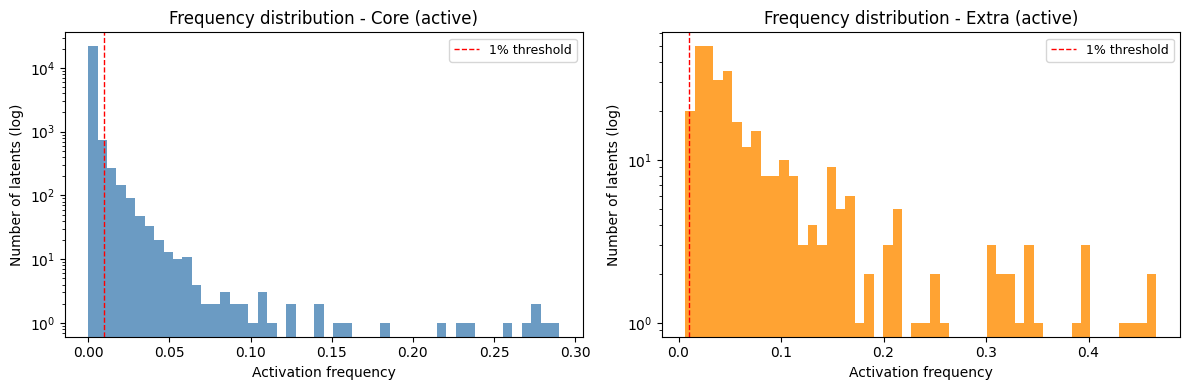

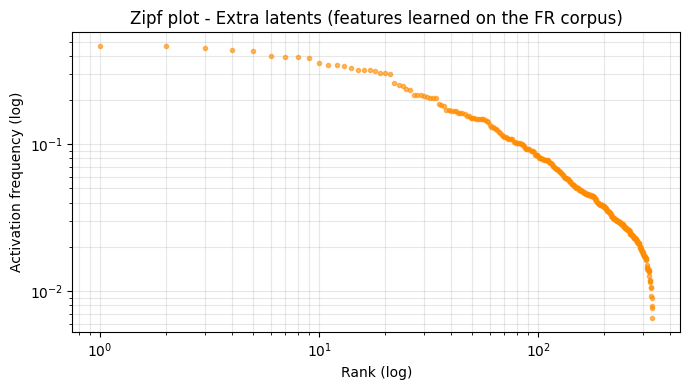

In [10]:
assert freq is not None, "Re-run the training cell (cell 7) first."

freq_core  = freq[:D_SAE_CORE]
freq_extra = freq[D_SAE_CORE:]

THRESH_ACTIVE = 0.01   # "active" threshold: > 1% of tokens
THRESH_DEAD   = 0.0    # never activated

# 1. Scalar statistics ----------------------------------------------------
print("-- Latent statistics --------------------------------------------------")
for label, f_arr, d_total in [
    ("Core ", freq_core,  D_SAE_CORE),
    ("Extra", freq_extra, D_EXTRA),
]:
    n_dead    = (f_arr == THRESH_DEAD).sum()
    n_active  = (f_arr  > THRESH_ACTIVE).sum()
    util_rate = n_active / d_total * 100
    non_zero  = f_arr[f_arr > 0]
    freq_mean = non_zero.mean() if non_zero.size else 0.0
    print(f"  {label} | d={d_total:6d} | dead={n_dead:5d} ({n_dead/d_total*100:.1f}%) "
          f"| active>{THRESH_ACTIVE*100:.0f}%={n_active:5d} ({util_rate:.1f}%) "
          f"| freq_max={f_arr.max():.4f} | freq_mean={freq_mean:.4f}")

print()
print("Top-10 extra latents by activation frequency:")
top_idx = np.argsort(freq_extra)[-10:][::-1]
for r, idx in enumerate(top_idx):
    print(f"  #{r+1:2d}  latent {idx + D_SAE_CORE:6d}  freq={freq_extra[idx]:.4f}")

# 2. Log-scale histogram --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, f_arr, label, color in [
    (axes[0], freq_core[freq_core > 0],   "Core (active)",  "steelblue"),
    (axes[1], freq_extra[freq_extra > 0], "Extra (active)", "darkorange"),
]:
    ax.hist(f_arr, bins=50, color=color, alpha=0.8, log=True)
    ax.axvline(THRESH_ACTIVE, color="red", linestyle="--", linewidth=1,
               label=f"{THRESH_ACTIVE*100:.0f}% threshold")
    ax.set_xlabel("Activation frequency")
    ax.set_ylabel("Number of latents (log)")
    ax.set_title(f"Frequency distribution - {label}")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# 3. Zipf plot of the extra latents --------------------------------------
sorted_extra = np.sort(freq_extra)[::-1]
ranks = np.arange(1, len(sorted_extra) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
mask = sorted_extra > 0
ax.loglog(ranks[mask], sorted_extra[mask], "o", markersize=3, color="darkorange", alpha=0.6)
ax.set_xlabel("Rank (log)")
ax.set_ylabel("Activation frequency (log)")
ax.set_title("Zipf plot - Extra latents (features learned on the FR corpus)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Qualitative analysis - Max-activating tokens per extra feature

**Protocol.**
1. Rebuild the Matryoshka from `mat_state_dict_cpu` (saved before `del m` in cell 7).
2. Token-level pass over a FR sub-corpus: for every token, collect the extra-feature activation
   vector $f_{\text{extra}} \in \mathbb{R}^{d_{\text{extra}}}$.
3. For the `TOP_K_FEATURES` most frequent extra features, display the `TOP_N_TOKENS` tokens
   that activate them most.

**Goal.** Check that the extra features capture semantic concepts distinct from the core
(expected: French technical terms, sub-tokens of compound words, etc.).


In [11]:
assert mat_state_dict_cpu is not None, "Re-run the training cell (cell 7) first."

TOP_K_FEATURES = 5    # number of extra features to analyse
TOP_N_TOKENS   = 15   # tokens to display per feature
N_TEXTS_INTERP = 80   # FR texts used for the forward pass (~80 * 128 * 768 * 4 = ~32 MB)

# 1. Matryoshka reconstruction -----------------------------------------------
gc.collect(); torch.cuda.empty_cache()

mat_eval = EncapsulatedMatryoshkaBatchTopK(
    pretrained=pretrained_sae, d_extra=D_EXTRA, k_extra=K_EXTRA,
).to(DEVICE)
mat_eval.load_state_dict(mat_state_dict_cpu)
mat_eval.eval()
print(f"Matryoshka rebuilt. VRAM: {torch.cuda.memory_allocated(DEVICE) / 1e6:.0f} MB")

# 2. Pick the extra features to analyse (top by frequency) -------------------
top_feat_indices = np.argsort(freq_extra)[-TOP_K_FEATURES:][::-1]
token_acts: dict = defaultdict(list)

# 3. Token-level pass --------------------------------------------------------
with torch.no_grad():
    for text in texts[:N_TEXTS_INTERP]:
        tokens = tl_model.to_tokens([text], prepend_bos=True).to(DEVICE)[:, :MAX_LENGTH]
        _, cache = tl_model.run_with_cache(tokens, names_filter=HOOK_NAME)
        acts_tok = cache[HOOK_NAME][0]

        out = mat_eval(acts_tok)
        fa  = out.feature_acts if hasattr(out, "feature_acts") else out["feature_acts"]
        fa_extra = fa[:, D_SAE_CORE:].cpu()

        token_ids  = tokens[0].cpu().tolist()
        token_strs = [tl_model.tokenizer.decode([tid]).strip() for tid in token_ids]

        for feat_rel in top_feat_indices:
            for tok_str, act_val in zip(token_strs, fa_extra[:, feat_rel].tolist()):
                if act_val > 1e-6:
                    token_acts[feat_rel].append((tok_str, act_val))
        del cache

print(f"Pass completed on {N_TEXTS_INTERP} texts.")

# 4. Display ------------------------------------------------------------------
print("\n-- Max-activating tokens per extra feature ------------------------")
for rank, feat_rel in enumerate(top_feat_indices):
    feat_abs = feat_rel + D_SAE_CORE
    freq_val = freq_extra[feat_rel]

    if not token_acts[feat_rel]:
        print(f"\nFeature #{rank+1} (latent {feat_abs}, freq={freq_val:.4f}): no activation recorded.")
        continue

    by_token: dict = defaultdict(float)
    for tok_str, act_val in token_acts[feat_rel]:
        by_token[tok_str] = max(by_token[tok_str], act_val)

    top_tokens = sorted(by_token.items(), key=lambda x: x[1], reverse=True)[:TOP_N_TOKENS]

    print(f"\nFeature #{rank+1}  latent_abs={feat_abs}  freq={freq_val:.4f}")
    print(f"  {'Token':<20s}  Max activation")
    print(f"  {'-' * 20}  {'-' * 14}")
    for tok_str, act_val in top_tokens:
        tok_display = repr(tok_str) if not tok_str.strip() else tok_str
        print(f"  {tok_display:<20s}  {act_val:.4f}")

# 5. Release ------------------------------------------------------------------
del mat_eval
gc.collect(); torch.cuda.empty_cache()
print(f"\nVRAM after release: {torch.cuda.memory_allocated(DEVICE) / 1e6:.0f} MB")


Matryoshka rebuilt. VRAM: 996 MB
Pass completed on 80 texts.

-- Max-activating tokens per extra feature ------------------------

Feature #1  latent_abs=24818  freq=0.4662
  Token                 Max activation
  --------------------  --------------
  iv                    8.9397
  ie                    8.4548
  i                     7.9454
  e                     7.9121
  ast                   7.8514
  et                    7.8220
  ante                  7.7709
  ion                   7.4268
  anson                 7.3671
  ord                   7.3314
  ille                  7.2809
  de                    7.2774
  é                     7.1409
  itation               6.9960
  is                    6.8500

Feature #2  latent_abs=25266  freq=0.4634
  Token                 Max activation
  --------------------  --------------
  su                    6.5324
  ident                 6.4104
  umi                   6.2076
  ,                     5.5598
  Na                    5.5580
  Staten

## 11. Summary

Recap of the headline numbers. **Work In Progress** - numbers will evolve as the protocol is
refined (more data, longer training, deduplicated corpus, etc.).


In [12]:
zs  = results_final["Initial (Zero-shot)"]
mat = results_final["Matryoshka (Frozen+Extra)"]
ft  = results_final["Fine-Tuned (Unfrozen)"]

delta_fve_fr_mat = mat["FR"]["FVE"] - zs["FR"]["FVE"]
delta_fve_fr_ft  = ft["FR"]["FVE"]  - zs["FR"]["FVE"]
forget_mat       = zs["EN"]["FVE"]  - mat["EN"]["FVE"]
forget_ft        = zs["EN"]["FVE"]  - ft["EN"]["FVE"]

n_dead_extra   = int((freq_extra == 0).sum())
n_active_extra = int((freq_extra > 0.01).sum())
util_rate      = n_active_extra / D_EXTRA * 100

print("=" * 70)
print("  SUMMARY - Matryoshka BatchTopK SAE (Frozen Core)")
print("=" * 70)
print()
print(f"  FR FVE gain   | Matryoshka: {delta_fve_fr_mat:+.6f}  |  Fine-tune: {delta_fve_fr_ft:+.6f}")
print(f"  EN forgetting | Matryoshka: {forget_mat:+.6f}  |  Fine-tune: {forget_ft:+.6f}")
print()
print(f"  Extra features (d={D_EXTRA}):")
print(f"    Dead (freq=0)       : {n_dead_extra}  ({n_dead_extra/D_EXTRA*100:.1f}%)")
print(f"    Active (>1% tokens) : {n_active_extra}  ({util_rate:.1f}%)")
print()
print("  PoC limitations (WIP):")
print("  - GPT-2 BPE tokeniser fragments FR words -> sub-lexical activations.")
print("  - Corpus size still limited -> extra features under-utilised.")
print("  - Extra-feature weights have not fully converged at this epoch budget.")


  SUMMARY - Matryoshka BatchTopK SAE (Frozen Core)

  FR FVE gain   | Matryoshka: +0.003701  |  Fine-tune: +0.005384
  EN forgetting | Matryoshka: +0.003239  |  Fine-tune: +0.000604

  Extra features (d=1024):
    Dead (freq=0)       : 693  (67.7%)
    Active (>1% tokens) : 326  (31.8%)

  PoC limitations (WIP):
  - GPT-2 BPE tokeniser fragments FR words -> sub-lexical activations.
  - Corpus size still limited -> extra features under-utilised.
  - Extra-feature weights have not fully converged at this epoch budget.
